In [1]:
import numpy as np
from numpy.linalg import eigh
from scipy.linalg import eigh, expm, svd
import sys
import os


import tenpy
from tenpy.networks.mps import MPS
from tenpy.algorithms import dmrg, tebd
from tenpy.networks.mpo import MPO
import warnings
from tenpy_toycodes.a_mps import SimpleMPS, init_FM_MPS, init_Neel_MPS
from tenpy_toycodes.b_model import TFIModel
from tenpy_toycodes.d_dmrg import SimpleDMRGEngine, SimpleHeff2, DMRG_tf_ising_finite
from tenpy_toycodes.tfi_exact import finite_gs_energy


import csv
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as tck

The bellow is a class constructed for the TFIM which is featured on the TeNPy website

In [29]:
L = 12
psi_FM = init_FM_MPS(L=L, d=2, bc='finite')
print(psi_FM)
SigmaZ = np.diag([1., -1.])
print(psi_FM.site_expectation_value(SigmaZ))

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [33]:
g = 1.2
model = TFIModel(L=L, J=1., g=g, bc='finite')

print("<H_bonds> = ", psi_FM.bond_expectation_value(model.H_bonds))
print("energy:", np.sum(psi_FM.bond_expectation_value(model.H_bonds)))

<H_bonds> =  [-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.]
energy: -11.0


In [64]:
L = 22
chi_max = 15
model = TFIModel(L=L, J=2.6, g=1, bc='finite')

psi = init_FM_MPS(model.L, 2, model.bc)
eng = SimpleDMRGEngine(psi, model, chi_max=chi_max, eps=1.e-10)
for i in range(20):
    E_dmrg = eng.sweep()
    E = np.sum(psi.bond_expectation_value(model.H_bonds))
    #print("sweep {i:2d}: E = {E:.13f}".format(i=i + 1, E=E))
print("final bond dimensions: ", psi.get_chi())
mag_x = np.mean(psi.site_expectation_value(model.sigmax))
mag_z = np.mean(psi.site_expectation_value(model.sigmaz))
print("magnetization in X = {mag_x:.5f}".format(mag_x=mag_x))
print("magnetization in Z = {mag_z:.5f}".format(mag_z=mag_z))
if model.L <= 16:
    E_exact = finite_gs_energy(L=model.L, J=model.J, g=model.g)
    print("err in energy = {err:.3e}".format(err=E - E_exact))

final bond dimensions:  [2, 4, 8, 12, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 12, 8, 4, 2]
magnetization in X = 0.21427
magnetization in Z = -0.00001


In [2]:
L = 12
J = 1.0
g = 1.2
E, psi, model = DMRG_tf_ising_finite(L, J, g)
op_i = model.sigmaz

psi.correlation_function(op_i, 3, op_i, 5)
#psi.quantum_Fisher_info(op_i)

[[ 1.  0.]
 [ 0. -1.]]


array(0.30260052)

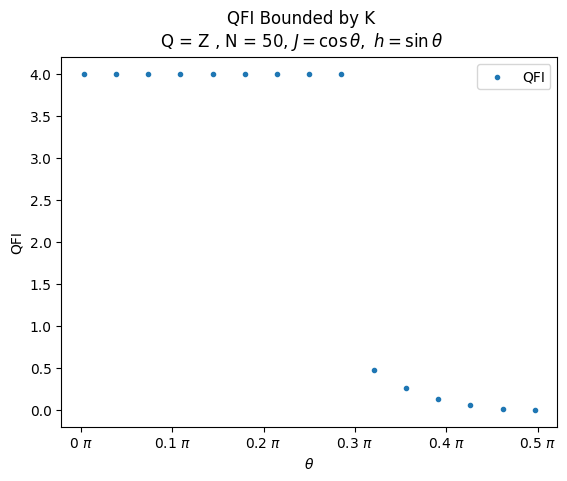

In [ ]:
L = 50
chi_max = 20
model = TFIModel(L=L, J=2.6, g=1, bc='finite')
op = model.sigmaz
num_points = 15

theta_range = np.linspace(.01, np.pi/2- .01, num_points)

fig, ax = plt.subplots(1)

LG_bound = []
QFI =[]
for theta in theta_range:
    #Generate LG_K lower bound
    J, g = np.sin(theta), np.cos(theta)
    E, psi, model = DMRG_tf_ising_finite(L, J, g)
    
    #Generate QFI
    QFI += [4 * (1 - psi.site_expectation_value( model.sigmaz)[L//2] ** 2)]

#ax.fill_between(theta_range/ np.pi, LG_bound, 4 ,  color = '.7', label = "QFI Bound "  )
ax.scatter(theta_range/ np.pi, QFI, marker = '.', label = "QFI", zorder = 3)

fig.suptitle("QFI Bounded by K\nQ = Z , N = " + str(L) + ", $J = \\cos\\theta,~h = \\sin\\theta$")
ax.xaxis.set_major_formatter(tck.FormatStrFormatter("%g $\\pi$"))
plt.xlabel("$\\theta$")
ax.set(ylabel = "QFI")
#plt.ylim((0.9,1.6))
plt.legend()

plt.show()

In [ ]:
#check that the correlation function and the QFI function agree